# Hot & Cloudy Master Plotting Script for Case Studies
##### Purpose: This notebook will input a date, then plot the day of conditions and the time series of the window surrounding them 
##### Version history: Created by A.D. 07/01/2025

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path
from functools import partial
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datetime import datetime

In [2]:
def master_plot(event_datetime, state):
    """
    Create a single figure containing:
        Row 1: Two synoptic maps (left: temp/MSLP/Z500, right: solar + wind CF)
        Row 2: Temperature anomaly
        Row 3: Solar CF anomaly
        Row 4: Wind CF anomaly
        Row 5: Demand anomaly
    """

    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    import cartopy.crs as ccrs

    # --- Create master figure ---
    fig = plt.figure(figsize=(18, 24))  # Taller figure for 5 rows
    gs = gridspec.GridSpec(
        5, 2,
        height_ratios=[1.2, 0.8, 0.8, 0.8, 0.8],  # Add 5th row
        width_ratios=[1, 1],
        hspace=0.35,
        wspace=0.25
    )

    # ============================
    # ROW 1 — SYNOPTIC MAPS
    # ============================

    ax_map1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
    ax_map2 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
    plot_synoptic(event_datetime, ax_map1, ax_map2)

    # ============================
    # ROW 2 — TEMPERATURE ANOMALY
    # ============================

    ax_temp = fig.add_subplot(gs[1, :])  # full-width row
    plot_temp(event_datetime, state, ax_temp)

    # ============================
    # ROW 3 — SOLAR ANOMALY
    # ============================

    ax_solar = fig.add_subplot(gs[2, :])  # full-width row
    plot_solar(event_datetime, state, ax_solar)

    # ============================
    # ROW 4 — WIND ANOMALY
    # ============================

    ax_wind = fig.add_subplot(gs[3, :])  # full-width row
    plot_wind(event_datetime, state, ax_wind)

    # ============================
    # ROW 5 — DEMAND ANOMALY
    # ============================

    ax_demand = fig.add_subplot(gs[4, :])  # full-width row
    plot_demand(event_datetime, state, ax_demand)

    # ============================
    # TITLE + LAYOUT
    # ============================

    fig.suptitle(
        f"Hot & Cloudy Case Study — {event_datetime.strftime('%Y-%m-%d %H:%M')} ({state})",
        fontsize=20,
        y=0.94
    )

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    return fig


In [3]:
def plot_synoptic(event_datetime, ax_left, ax_right):
    """
    Draw the Hot & Cloudy synoptic maps onto two provided axes.

    Parameters
    ----------
    event_datetime : datetime.datetime
    ax_left  : matplotlib axis for the temperature/MSLP/Z500 panel
    ax_right : matplotlib axis for the solar + wind CF hatching panel
    """

    import numpy as np
    import xarray as xr
    import pandas as pd
    from pathlib import Path
    from functools import partial
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    from matplotlib.colors import LinearSegmentedColormap
    import matplotlib.patches as mpatches

    # -----------------------------
    # Preprocess helper
    # -----------------------------
    def _preprocess(ds, lon_bnds=None, lat_bnds=None, timesel=None):
        if timesel is not None:
            ds = ds.sel(time=timesel, method='nearest')
        if lon_bnds and lat_bnds:
            ds = ds.sel(lon=slice(*lon_bnds), lat=slice(*lat_bnds))
        return ds

    # -----------------------------
    # BARRA2 loader
    # -----------------------------
    def get_BARRA2_fields(fdate):
        fstring = fdate.strftime('%Y%m-%Y%m.nc')

        fname_msl = '/g/data/ob53/BARRA2/output/reanalysis/AUS-11/BOM/ERA5/historical/hres/BARRA-R2/v1/1hr/psl/v20250528/psl_AUS-11_ERA5_historical_hres_BOM_BARRA-R2_v1_1hr_' + fstring
        fname_u   = '/g/data/ob53/BARRA2/output/reanalysis/AUS-11/BOM/ERA5/historical/hres/BARRA-R2/v1/1hr/ua100m/v20250528/ua100m_AUS-11_ERA5_historical_hres_BOM_BARRA-R2_v1_1hr_' + fstring
        fname_v   = '/g/data/ob53/BARRA2/output/reanalysis/AUS-11/BOM/ERA5/historical/hres/BARRA-R2/v1/1hr/va100m/v20250528/va100m_AUS-11_ERA5_historical_hres_BOM_BARRA-R2_v1_1hr_' + fstring
        fname_tasmax = '/g/data/ob53/BARRA2/output/reanalysis/AUS-11/BOM/ERA5/historical/hres/BARRA-R2/v1/1hr/tasmax/v20250528/tasmax_AUS-11_ERA5_historical_hres_BOM_BARRA-R2_v1_1hr_' + fstring
        fname_zg500  = '/g/data/ob53/BARRA2/output/reanalysis/AUS-11/BOM/ERA5/historical/hres/BARRA-R2/v1/1hr/zg500/latest/zg500_AUS-11_ERA5_historical_hres_BOM_BARRA-R2_v1_1hr_' + fstring

        partial_func = partial(_preprocess, lon_bnds=lon_bnds, lat_bnds=lat_bnds, timesel=fdate)

        dmslp  = xr.open_mfdataset(fname_msl, preprocess=partial_func)
        dsu    = xr.open_mfdataset(fname_u,   preprocess=partial_func)
        dsv    = xr.open_mfdataset(fname_v,   preprocess=partial_func)
        dtmax  = xr.open_mfdataset(fname_tasmax, preprocess=partial_func)
        dzg500 = xr.open_mfdataset(fname_zg500,  preprocess=partial_func)

        return dmslp, dsu, dsv, dtmax, dzg500

    # -----------------------------
    # Himawari loader
    # -----------------------------
    times = [f"{h:02d}{m:02d}" for h in range(7) for m in range(0, 60, 10)]

    def get_date_solar(date):
        year = date.year
        month = f"{date.month:02d}"
        day = f"{date.day:02d}"

        version = "v1.0" if date <= pd.Timestamp("2019-03-31") else "v1.1"
        dir_path = Path(f"/g/data/rv74/satellite-products/arc/der/himawari-ahi/solar/p1s/{version}/{year}/{month}/{day}/")

        all_files = list(dir_path.glob("*.nc"))
        files = [f for f in all_files if any(t in f.name for t in times)]

        solar = xr.open_mfdataset(
            files,
            chunks="auto",
            concat_dim="time",
            combine="nested",
            coords="minimal",
            compat="override",
            parallel=True,
        )
        return solar.surface_global_irradiance

    # -----------------------------
    # Domain bounds
    # -----------------------------
    lon_bnds = (110, 160)
    lat_bnds = (-45, -9)

    # -----------------------------
    # Load data
    # -----------------------------
    dmslp, dsu, dsv, dtmax, dzg500 = get_BARRA2_fields(event_datetime)

    dsolar = get_date_solar(event_datetime)
    dsolar = dsolar.sel(time=event_datetime.strftime("%Y-%m-%dT%H:%M:%S"))

    # -----------------------------
    # Wind → capacity factor
    # -----------------------------
    dws = (dsu["ua100m"]**2 + dsv["va100m"]**2)**0.5

    def capacity_factor(W):
        W_0, W_r, W_1 = 3.5, 13, 25
        cf = (W**3 - W_0**3) / (W_r**3 - W_0**3)
        cf = cf.where(W >= W_0, 0)
        cf = cf.where(W < W_r, 1)
        cf = cf.where(W < W_1, 0)
        return cf.where(W.notnull(), np.nan)

    dcf = capacity_factor(dws)

    # -----------------------------
    # Extract fields
    # -----------------------------
    mslp  = dmslp["psl"]/100
    tmax  = dtmax["tasmax"] - 273.15
    cf    = dcf
    solar = dsolar
    zg500 = dzg500["zg500"]

    lon, lat = mslp["lon"].values, mslp["lat"].values
    lon2d, lat2d = np.meshgrid(lon, lat)

    slon, slat = solar["longitude"].values, solar["latitude"].values
    slon2d, slat2d = np.meshgrid(slon, slat)

    # -----------------------------
    # Plotting on provided axes
    # -----------------------------
    for ax in (ax_left, ax_right):
        ax.set_extent([110, 160, -45, -9])
        ax.coastlines(resolution="10m")
        ax.add_feature(cfeature.BORDERS, linestyle=":")

    # --- Panel 1: Temp + MSLP + Z500 ---
    cf_temp = ax_left.contourf(lon2d, lat2d, tmax.values, cmap="hot_r", levels=21, extend="both", alpha=0.4)
    cs1 = ax_left.contour(lon2d, lat2d, mslp.values, levels=10, colors="black", linewidths=1)
    ax_left.contour(lon2d, lat2d, zg500.values, levels=10, colors="darkgrey", linewidths=1, linestyles="--")

    ax_left.clabel(cs1, fmt="%d", inline=True, fontsize=8)
    ax_left.set_title("Daily Max Temp, MSLP (contours), 500hPa GPH (--- contours)")

    # --- Panel 2: Solar + CF hatching ---
    grey_yellow = LinearSegmentedColormap.from_list("grey_yellow", ["lightsteelblue", "#FDFD97"])
    cf_solar = ax_right.contourf(slon2d, slat2d, solar.values, cmap=grey_yellow, levels=20, extend="both")

    hatch_levels = [0, 0.25, 0.5, 0.75, 1.01]
    hatches = ["", "//", "///", "/////"]

    for i in range(4):
        mask = (cf.values >= hatch_levels[i]) & (cf.values < hatch_levels[i+1])
        ax_right.contourf(lon2d, lat2d, mask, levels=[0.5, 1.5], hatches=[hatches[i]], colors="none")

    ax_right.set_title("Solar Radiation & Wind CF")

    # --- Hatching legend ---
    hatch_labels = [
        "CF 0.00–0.25",
        "CF 0.25–0.50",
        "CF 0.50–0.75",
        "CF 0.75–1.00"
    ]

    hatch_handles = [
        mpatches.Patch(facecolor='white', hatch=hatches[i], label=hatch_labels[i], edgecolor='black')
        for i in range(4)
    ]

    ax_right.legend(
        handles=hatch_handles,
        title="Wind Capacity Factor",
        loc="upper left",
        frameon=True,
        fontsize=6
    )

    plt.colorbar(cf_temp, ax=ax_left, orientation='vertical', pad=0.02, shrink=0.8, label='Daily max temp (°C)')
    plt.colorbar(cf_solar, ax=ax_right, orientation='vertical', pad=0.02, shrink=0.8, label='Surface downwelling shortwave flux (W/m²)')


In [9]:
def plot_temp(event_datetime, state, ax):
    """
    Plot hourly temperature anomaly by state for a 7-day window around a given datetime.
    Draws onto a provided axis (ax) for use in a master figure.

    Parameters:
    - event_datetime (datetime)
    - state (str)
    - ax (matplotlib axis)
    """
    # === Load data ===
    fname_his_tas = "/home/565/ad1803/Hot_Cloudy/Demand/output_data/barra/tas/tas_barra-c2_hourly_1984-2024_NEM_pop_dens_mask_*.nc"
    dhis_tas = xr.open_mfdataset(fname_his_tas)
    tas = dhis_tas['tas']

    tas["time"] = [i + pd.DateOffset(hours=10) for i in tas.time.values]

    # === Remove leap day ===
    tas = tas.sel(time=tas.time.dt.dayofyear != 366)

    # === Compute climatology ===
    by_doy = tas.groupby(tas.time.dt.dayofyear)
    climatology = by_doy.map(lambda x: x.groupby(x.time.dt.hour).mean('time'))

    # === Compute anomaly ===
    tas_anom = by_doy.map(
        lambda x: x.groupby(x.time.dt.hour) - 
        climatology.sel(dayofyear=x.time.dt.dayofyear.values[0])
    )

    # === Define time window ===
    event_day = pd.Timestamp(event_datetime.date())
    start_date = event_day - pd.Timedelta(days=5)
    end_date = event_day + pd.Timedelta(days=2)

    tas_anom_window = tas_anom.sel(time=slice(start_date, end_date))

    # === Plotting ===
    colours = ["white", "#F0B884", "#C5ACE8", "#EB9DA2", "#ACBBE8", "#BBEBB5"]
    regions = tas_anom_window.region.values

    for i, region in enumerate(regions):
        region_name = str(region)
        lw = 4 if region_name == state else 1

        ax.plot(
            tas_anom_window.time,
            tas_anom_window.sel(region=region),
            label=region_name,
            color=colours[i % len(colours)],
            lw=lw
        )

    # Highlight event day
    start_of_day = event_day
    end_of_day = event_day + pd.Timedelta(days=1)
    ax.axvspan(start_of_day, end_of_day, color='lightgrey', alpha=0.4)

    # Styling
    ax.set_title("Hourly 2m Temp Anomaly (vs DOY-Hour Climatology)", fontsize=12)
    ax.set_xlabel("Time")
    ax.set_ylabel("Temperature Anomaly (°C)")
    ax.axhline(0, color='dimgrey', linestyle='-', lw=3)
    ax.grid(True)
    ax.legend(fontsize=8)

In [5]:
def plot_solar(event_datetime, state, ax):
    """
    Loads solar PV data, preprocesses it, computes capacity factor anomaly (actual - ideal),
    and plots it for all regions around a given event datetime onto a provided axis.

    Parameters:
    - event_datetime (datetime)
    - state (str): Australian state abbreviation (e.g., 'QLD', 'NSW', 'VIC')
    - ax (matplotlib axis): Axis to draw the plot on
    """

    import xarray as xr
    import pandas as pd
    import numpy as np
    from pathlib import Path

    # === Load and combine datasets ===
    data_dir = Path('/g/data/gb02/cd3022/hot-and-cloudy/solar-pv/GCCSA/ideal-actual')
    files = list(data_dir.glob("*.nc"))
    datasets = []

    for file in files:
        region_name = file.stem[1:5]   # e.g. GBRI, GMEL, etc.
        ds_reg = xr.open_dataset(file)
        ds_reg = ds_reg.expand_dims(region=[region_name])
        datasets.append(ds_reg)

    ds = xr.concat(datasets, dim='region')

    # === Preprocessing (keep EXACTLY as-is) ===
    time_utc = pd.to_datetime(ds.time.values)
    time_aest = time_utc.tz_localize("UTC").tz_convert("Australia/Brisbane")
    time_aest_naive = time_aest.tz_convert("Australia/Brisbane").tz_localize(None)
    ds = ds.assign_coords(time=("time", time_aest_naive))

    ds = ds.where(ds['time'].dt.strftime('%H:%M') != '12:40', drop=True)

    bad_days = [
        np.datetime64('2019-08-12'),
        np.datetime64('2019-10-01'),
        np.datetime64('2020-09-06'),
    ]

    ds_dates = ds['time'].dt.floor('D')
    good_time_mask = ~ds_dates.isin(bad_days)
    ds = ds.sel(time=ds['time'][good_time_mask])

    rated_capacity = 219.656729124
    ds = ds.apply(lambda x: x / rated_capacity)

    ds = xr.where(ds.isnull(), 0, ds)

    # === Map state to region ===
    state_to_region = {
        "QLD": "GBRI",
        "NSW": "GSYD",
        "VIC": "GMEL",
        "SA":  "GADE",
        "TAS": "GHOB",
        "ACT": "ACTE",
    }

    highlight_region = state_to_region.get(state.upper(), None)
    if highlight_region is None:
        raise ValueError(f"State '{state}' not recognized. Use one of: {list(state_to_region.keys())}")

    # === Define time window ===
    event_day = pd.Timestamp(event_datetime.date())
    start_date = event_day - pd.Timedelta(days=5)
    end_date = event_day + pd.Timedelta(days=2)

    # === Subset to time window ===
    actual_window = ds.actual.sel(time=slice(start_date, end_date))
    ideal_window = ds.ideal.sel(time=slice(start_date, end_date))
    diff_window = actual_window - ideal_window

    # === Plotting on provided axis ===
    colours = ["#E89DA2", "#F0B884", "#FDFD97", "#BBE8B5", "#ACBBE8", "#C5ACE8"]

    for i, reg in enumerate(ds.region):
        region_name = str(reg.values)
        lw = 4 if region_name == highlight_region else 1

        ax.plot(
            diff_window.time,
            diff_window.sel(region=reg),
            label=f"{region_name} (actual - ideal)",
            color=colours[i % len(colours)],
            lw=lw
        )

    # Highlight event day
    start_of_day = event_day
    end_of_day = event_day + pd.Timedelta(days=1)
    ax.axvspan(start_of_day, end_of_day, color='lightgrey', alpha=0.4)

    # Styling
    ax.set_title('Solar CF Anomaly: Actual - Ideal (7-day window)', fontsize=12)
    ax.set_ylabel('Capacity Factor Difference')
    ax.set_xlabel('Time')
    ax.axhline(0, color='grey', linestyle='--', lw=1)
    ax.grid(True)
    ax.legend(fontsize=8)


In [6]:
def plot_wind(event_datetime, highlight_state, ax):
    """
    Plots capacity factor time series for Australian states around a given event date.
    
    Parameters:
    - event_date (str or pd.Timestamp): Date of the event (e.g., '2021-01-14')
    - highlight_state (str): State to highlight with a thicker line (e.g., 'NSW')
    """
    # Load data
    fname_barra_cf = "/home/565/ad1803/Hot_Cloudy/Case_Studies/Output_data/cf100m_by_state_*.nc"
    dcf = xr.open_mfdataset(fname_barra_cf)

    dcf["time"] = [i + pd.DateOffset(hours=10) for i in dcf.time.values]
    
    # Convert date and define range
    event_day = pd.Timestamp(event_datetime.date())
    start_date = event_day - pd.Timedelta(days=5)
    end_date = event_day + pd.Timedelta(days=2)

    # Subset data
    cf_subset = dcf.sel(time=slice(start_date, end_date))

    # Plot settings
    colours = ["#EB9DA2", "#F0B884", "#C5ACE8", "#ACBBE8", "#BBEBB5"]
    states = ["QLD", "NSW", "VIC", "SA", "TAS"]

    for i, state in enumerate(states):
        linewidth = 4 if state == highlight_state else 1
        ax.plot(cf_subset.time, cf_subset[state], label=state, color=colours[i], lw=linewidth)

    # Highlight event day
    start_of_day = pd.Timestamp(event_day.date())
    end_of_day = start_of_day + pd.Timedelta(days=1)
    ax.axvspan(start_of_day, end_of_day, color='lightgrey', alpha=0.4, label='Event Day')

    # Styling
    ax.set_title("Wind Capacity Factor Time Series by State")
    ax.set_xlabel("Time")
    ax.set_ylabel("Wind Capacity Factor")
    ax.legend(fontsize=8)
    ax.grid(True)

In [7]:
def plot_demand(event_datetime, highlight_state, ax):
    """
    Plots electricity demand anomalies (in standard deviations) for Australian states
    around a given event date, using 2017–2018 hour-of-day climatology computed
    individually for each state.
    """

    # Load CSV demand data
    fname_demand = "/home/565/ad1803/Hot_Cloudy/Demand/input_data/hourly_demand_20090701-20231230.csv"
    df = pd.read_csv(fname_demand)

    # Convert SETTLEMENTDATE to datetime and set as index
    df["SETTLEMENTDATE"] = pd.to_datetime(df["SETTLEMENTDATE"])
    df = df.set_index("SETTLEMENTDATE")

    # Add hour-of-day column
    df["hour"] = df.index.hour

    # -----------------------------
    # 1. Select climatology period
    # -----------------------------
    clim = df.loc["2017-01-01":"2018-12-31"]

    # States to process
    states = ["QLD", "NSW", "VIC", "SA", "TAS"]

    # Compute hour-of-day climatology *per state*
    clim_mean = clim.groupby("hour")[states].mean()
    clim_std  = clim.groupby("hour")[states].std()

    # -----------------------------
    # 2. Select event window
    # -----------------------------
    event_day = pd.Timestamp(event_datetime.date())
    start_date = event_day - pd.Timedelta(days=5)
    end_date   = event_day + pd.Timedelta(days=2)

    demand_subset = df.loc[start_date:end_date].copy()
    hours = demand_subset.index.hour

    # -----------------------------
    # 3. Compute hourly anomalies
    # -----------------------------
    demand_anom = (demand_subset[states].values -
                   clim_mean.loc[hours].values) / \
                  clim_std.loc[hours].values

    demand_anom = pd.DataFrame(
        demand_anom,
        index=demand_subset.index,
        columns=states
    )

    # -----------------------------
    # 4. Plot
    # -----------------------------
    colours = ["#EB9DA2", "#F0B884", "#C5ACE8", "#ACBBE8", "#BBEBB5"]

    for i, state in enumerate(states):
        lw = 4 if state == highlight_state else 1
        ax.plot(
            demand_anom.index,
            demand_anom[state],
            label=state,
            color=colours[i],
            lw=lw
        )

    # Highlight event day
    start_of_day = pd.Timestamp(event_day)
    end_of_day   = start_of_day + pd.Timedelta(days=1)
    ax.axvspan(start_of_day, end_of_day, color="lightgrey", alpha=0.4)

    # Styling
    ax.set_title("Electricity Demand Anomalies by State (2017–2018 Hourly σ)")
    ax.set_xlabel("Time")
    ax.set_ylabel("Anomaly (σ)")
    ax.legend(fontsize=8)
    ax.axhline(0, color='dimgrey', linestyle='-', lw=3)
    ax.grid(True)


/jobfs/159743664.gadi-pbs/ipykernel_2734784/1340217284.py:70: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  solar = xr.open_mfdataset(
/jobfs/159743664.gadi-pbs/ipykernel_2734784/3551255541.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97])


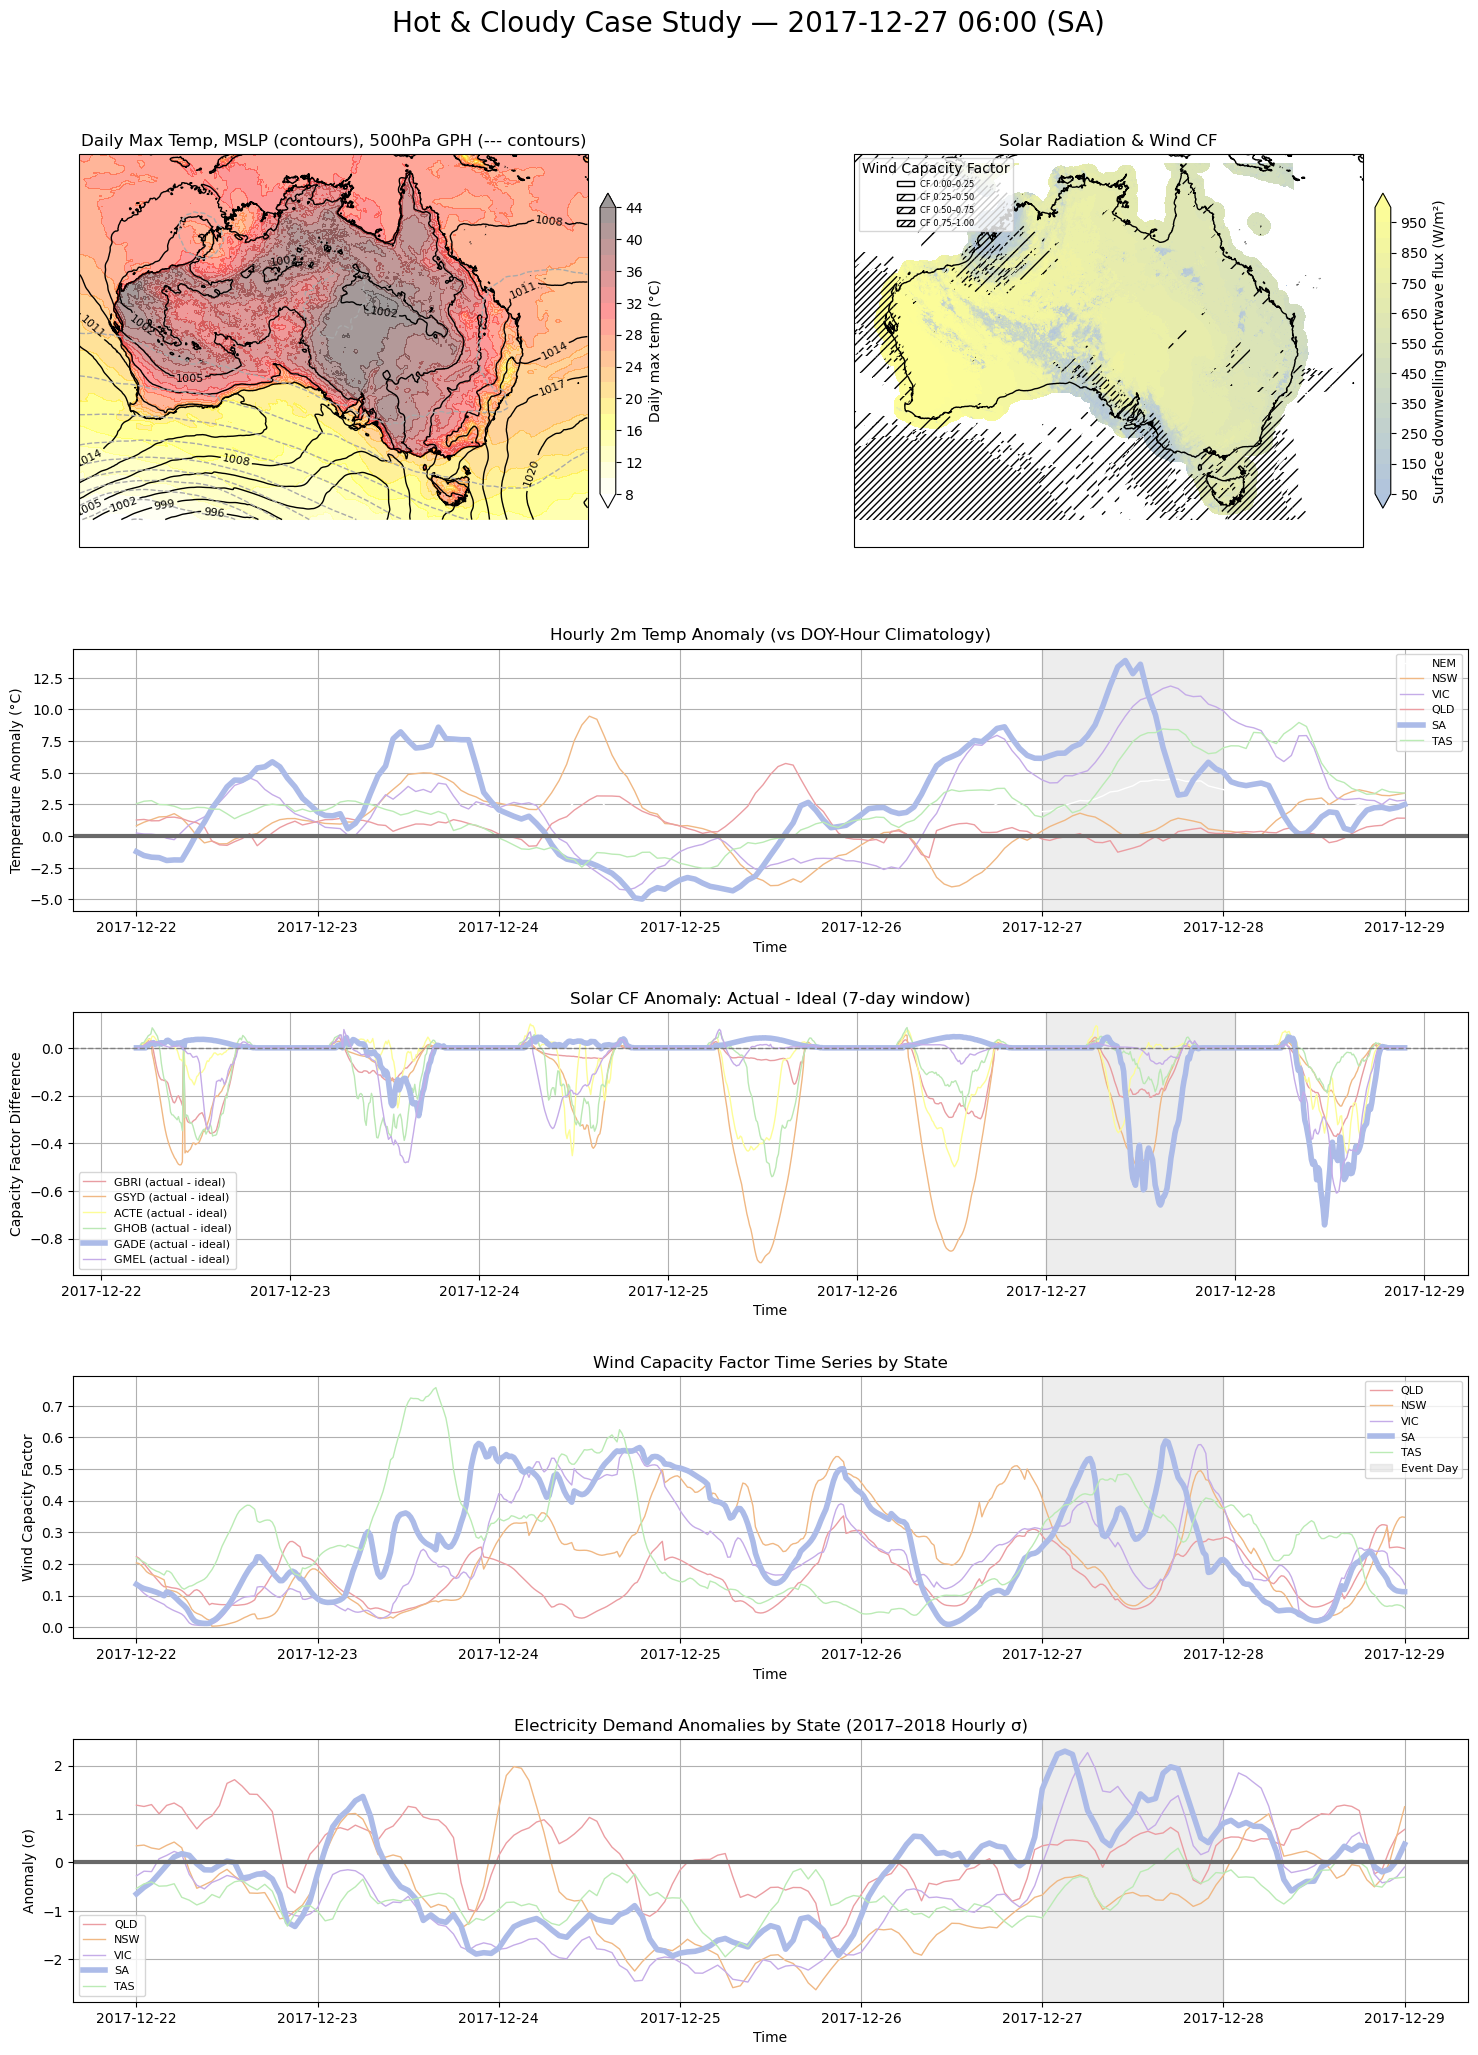

In [11]:
event_datetime = datetime(2017, 12, 27, 6)
state = 'SA'

fig = master_plot(event_datetime, state)

timestamp = event_datetime.strftime("%Y%m%d%H")
filename = f"Fin_Casestudy_{state}_{timestamp}.png"

fig.savefig(f"/home/565/ad1803/Hot_Cloudy/Case_Studies/Plots/{filename}", dpi=200)